# **Generate the input pickle file from the glacier image for the simulation**
This notebook generates the requiered pickle file for the simulation of the bottom topography of the Tsanfleuron glacier.

### **Input** : 
* path to the training image of the glacier in a tiff format.
* path to the glacier mask in a tiff format.
* path to the GPR point set csv

### **Output** : 
* .pickle binary files to be open with the simulation script

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import geopandas as gpd
import georasters as gr
import time 
from random import seed
seed(1)
from random import random
import csv


import tkinter as tk
from tkinter import filedialog

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/pysal/__init__.py:65: VisibleDeprecationWarning: PySAL's API will be changed on 2018-12-31. The last release made with this API is version 1.14.4. A preview of the next API version is provided in the `pysal` 2.0 prelease candidate. The API changes and a guide on how to change imports is provided at https://pysal.org/about
  ), VisibleDeprecationWarning)


## Import the data 
The DEM will be put in the same grid than the simulation grid (mask grid), in order to ease the volume estimation after the simulations. (ON PEUT REMOVE LE DEM)

In [2]:
file_path_ti      = '../../../../../99_Data/tsanfleuron/ti_cyprien_null.tif'
file_path_glacier = '../../../../../99_Data/tsanfleuron/dem_glacier_cyprien.tif'
file_path_mask    = '../../../../../99_Data/tsanfleuron/mask_glacier.tif'

if os.path.isfile(file_path_ti):
    print('Le fichier est présent. import')
    data_ti = gr.from_file(file_path_ti)
    (xmin, xsize, x, ymax, y, ysize) = data_ti.geot

else:
    print('error')

    
if os.path.isfile(file_path_glacier):
    print('Le fichier est présent. import')
    data_dem = gr.from_file(file_path_glacier
                           )

else:
    print('error')
    
    
if os.path.isfile(file_path_mask):
    print('Le fichier est présent. import')
    data_mask = gr.from_file(file_path_mask
                           )

else:
    print('error')


    
print('\nInfos')
print('DEM geometry :' + str(data_ti.geot))
print('DEM shape :'+ str(data_ti.shape))

Le fichier est présent. import
Le fichier est présent. import
Le fichier est présent. import

Infos
DEM geometry :(582132.0, 2.0, 0.0, 131232.0, 0.0, -2.0)
DEM shape :(1566, 3531)


In [3]:
with open('ti_cyprien.pickle','wb') as f:
    pickle.dump(data_ti.raster.data,f, pickle.HIGHEST_PROTOCOL)

In [4]:
data_dem.raster.data[data_mask.raster!=1] =np.nan

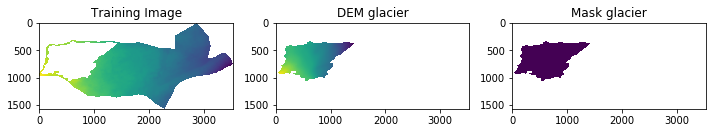

In [5]:
data_ti.raster.data[data_ti.raster==data_ti.min()]=np.nan

fig, ax = plt.subplots(1,3,figsize=(10,10))
plt.subplot(1,3,1)
plt.imshow(data_ti.raster)
plt.title('Training Image')
plt.subplot(1,3,2)
plt.imshow(data_dem.raster)
plt.title('DEM glacier')
plt.subplot(1,3,3)
plt.imshow(data_mask.raster)
plt.title('Mask glacier')
plt.tight_layout()
plt.show()

In [6]:
fig.savefig('input.png')

In [7]:
#Import the point set hard data
path_csv = '../data/PointSet/csv/'
Hard_GPR = pd.read_csv(path_csv+'bedRock_GPR.csv',delimiter =';')
#Hard_MNT = pd.read_csv(path_csv+'bedRock_MNT.csv',delimiter='\t')

## We create a new mask/mesh that regroupe the glacier and the ti and clean the hard data set

In [11]:
#Create a mesh grid witht the dimension of the DEM ### c'est pour faire quoi?
x_v = np.array(range(data_ti.shape[1]))*data_ti.geot[1] + data_ti.geot[0]
y_v = np.array(range(data_ti.shape[0]))*data_ti.geot[5] + data_ti.geot[3]
X_dem, Y_dem = np.meshgrid(x_v,y_v)

In [12]:
#Clean the point Set data to the geometry of the mask  ### c'est bien ça, tu clean les hard data?

#Hard_pts = Hard_MNT.append(Hard_GPR[['X','Y','Bed_Alt']])
Hard_pts = Hard_GPR.copy()
borders  = [X_dem.min(),X_dem.max(),Y_dem.min(),Y_dem.max(), Hard_pts['X'].min(), Hard_pts['X'].max(),Hard_pts['Y'].min(), Hard_pts['Y'].max()]

x_min = min(borders[0],borders[4])
x_max = max(borders[1],borders[5])
y_min = min(borders[2],borders[6])
y_max = max(borders[3],borders[7])

nx = np.int(np.ceil((x_max - x_min)/2))
ny = np.int(np.ceil((y_max - y_min)/2))
referential = [x_min, y_max]

#Add to the data frame the cell_x and cell_y coordinate
Hard_pts.insert(0,'cell_x',np.around((Hard_pts['X']-referential[0])/data_ti.geot[1],decimals=0))
Hard_pts.insert(1,'cell_y',np.around((Hard_pts['Y']-referential[1])/data_ti.geot[5],decimals=0))

#Remove the points that share the same cell_x and cell_y
Hard_pts = Hard_pts.drop_duplicates(subset = ['cell_x','cell_y'] )
Hard_pts.rename(columns={'Bed_Alt':'alt'}, inplace=True)
Hard_pts = Hard_pts.drop(columns=['depth','Z'])

In [13]:
Hard_pts.head()

,cell_x,cell_y,X,Y,alt
0,136.0,357.0,582404.5841,130518.0406,2792.731
1,132.0,350.0,582395.5218,130531.0831,2799.314
2,142.0,368.0,582416.0519,130495.6199,2788.426
3,148.0,378.0,582428.2737,130475.9283,2788.680
4,150.0,381.0,582432.0730,130470.5054,2791.285


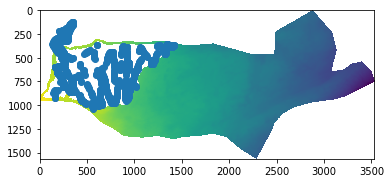

In [14]:
plt.imshow(data_ti.raster)
plt.scatter(Hard_pts.cell_x,Hard_pts.cell_y)
plt.show()

## We create the output data

In [12]:
#Training image
ti = np.copy(data_ti.raster.data)
ti[ti==-1] = np.nan

In [13]:
#Mask glacier
mask_glacier = np.copy(data_mask.raster.data)
mask_glacier[mask_glacier!=1]=0

In [17]:
#Mask large
mask_large = np.copy(ti)
mask_large[mask_large>0]=1
mask_large[mask_large!=1]=0
mask_large[mask_glacier==1]=1

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in greater
  This is separate from the ipykernel package so we can avoid doing imports until


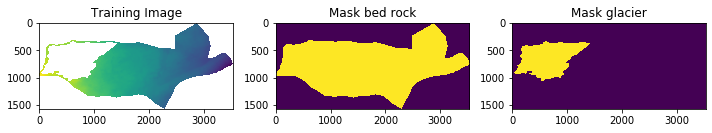

In [15]:
plt.subplots(1,3,figsize=(10,10))
plt.subplot(1,3,1)
plt.imshow(ti)
plt.title('Training Image')
plt.subplot(1,3,2)
plt.imshow(mask_large)
plt.title('Mask bed rock')
plt.subplot(1,3,3)
plt.imshow(mask_glacier)
plt.title('Mask glacier')
plt.tight_layout()
plt.show()

## Remove the trend in the data

### Data preparation

In [17]:
#TI to points data set like
ti_trend = np.copy(data_ti.raster.data)

x     = np.arange(0,ti_trend.shape[1],1)
y     = np.arange(0,ti_trend.shape[0],1)
X,Y   = np.meshgrid(x,y)

ti_f = ti_trend.flatten()
X    = X.flatten()
X    = X[~np.isnan(ti_f)]
Y    = Y.flatten()
Y    = Y[~np.isnan(ti_f)]
ti_f = ti_f[~np.isnan(ti_f)]

X.shape, Y.shape, ti_f.shape

((2227881,), (2227881,), (2227881,))

In [18]:
Hard_pts.head()

,cell_x,cell_y,X,Y,alt
0,136.0,357.0,582404.5841,130518.0406,2792.731
1,132.0,350.0,582395.5218,130531.0831,2799.314
2,142.0,368.0,582416.0519,130495.6199,2788.426
3,148.0,378.0,582428.2737,130475.9283,2788.680
4,150.0,381.0,582432.0730,130470.5054,2791.285


In [19]:
#GPR data
x_gpr   = Hard_pts.cell_x.values
y_gpr   = Hard_pts.cell_y.values
alt_gpr = Hard_pts.alt.values
x_gpr.shape, y_gpr.shape, alt_gpr.shape

((1513,), (1513,), (1513,))

In [20]:
#Concatenate the two data set
X_all = np.append(X,x_gpr)
Y_all = np.append(Y,y_gpr)
Z_all = np.append(ti_f, alt_gpr)

In [21]:
#Polynomial data preparation
from sklearn.preprocessing import PolynomialFeatures
X_fit = np.c_[X_all,Y_all]
polynomial_features = PolynomialFeatures(degree=2)
X_poly = polynomial_features.fit_transform(X_fit)

In [22]:
#Linear regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_poly, Z_all)
Z_poly = model.predict(X_poly)

In [23]:
#Delete the trend of the original data
ti_trend_poly = Z_poly[0:len(ti_f)]
ti_no_trend = ti_f-ti_trend_poly
alt_gpr_no_trend = Z_poly[len(ti_f):]
alt_gpr_no_trend = alt_gpr-alt_gpr_no_trend

In [24]:
#We can reshape the ti_no_trend for the export
ti_noT = np.copy(ti_trend)
ti_noT[~np.isnan(ti_trend)] = ti_no_trend

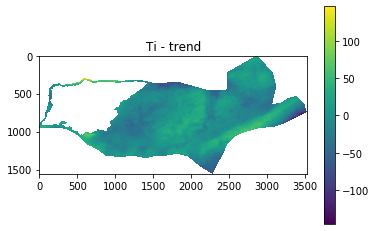

In [25]:
plt.imshow(ti_noT)
plt.colorbar()
plt.title('Ti - trend')
plt.show()

In [26]:
#And store the trend to re-add it after simulation
ti_onlyT = np.copy(ti_trend)
ti_onlyT[~np.isnan(ti_trend)] = ti_trend_poly

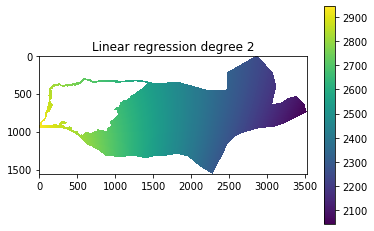

In [27]:
plt.imshow(ti_onlyT)
plt.colorbar()
plt.title('Linear regression degree 2')
plt.show()

In [28]:
#For the GPR we replace the alt with the alt-trend. 
#The trend on the whole zone will have to be calculate after the simulation.
Hard_pts_noT = Hard_pts.copy()
Hard_pts_noT.alt = alt_gpr_no_trend
Hard_pts_noT.head()

,cell_x,cell_y,X,Y,alt
0,136.0,357.0,582404.5841,130518.0406,-31.111542
1,132.0,350.0,582395.5218,130531.0831,-24.177600
2,142.0,368.0,582416.0519,130495.6199,-36.009551
3,148.0,378.0,582428.2737,130475.9283,-36.161810
4,150.0,381.0,582432.0730,130470.5054,-33.633133


#### Export the TI as csv for variogramme interpretation on ar2gems

In [58]:
ti_no_trend = ti_no_trend[np.newaxis,:]
X = X[np.newaxis,:]
Y = Y[np.newaxis,:]

ti_no_trend.shape, X.shape, Y.shape

((1, 2227881), (1, 2227881), (1, 2227881))

In [75]:
ti_no_trend = np.transpose(ti_no_trend)
X = np.transpose(X)
Y = np.transpose(Y)

In [83]:
X[:,0].shape

(2227881,)

In [99]:
ti_df_to_export = pd.DataFrame({'X':X[:,0], 'Y':Y[:,0], 'alt':ti_no_trend[:,0]})

In [109]:
ti_df_to_export = ti_df_to_export.sample(frac = 0.5)

In [110]:
len(ti_df_to_export)

6962

In [111]:
ti_df_to_export.to_csv('ti_noTrend2.csv')

#### Export the Hard data for variogramme interpretation on ar2gems

In [29]:
hd_export = Hard_pts_noT.copy()
hd_export = hd_export.drop(columns=['X','Y'], axis=1)

In [31]:
hd_export.to_csv('hd_noTrend.csv')

## We export the data for the simulations

In [24]:
#Clear and create the empty directory for the pickle file
save_path   = '../real_data'

if not(os.path.exists(save_path)):
    os.mkdir(save_path)
else:
    for root, dirs, files in os.walk(save_path, topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))
        
    os.rmdir(save_path)
    os.mkdir(save_path)

In [25]:
#Save the data
#The data are : [true Mnt, position of the mask, hard_data, ti, [mask_glacier, mask_glacier+ti]
with open(save_path + '/' + 'tsanfleuron_data' + '.pickle', 'wb') as f:  # Python 3: open(..., 'wb')
    pickle.dump([None, [0,nx+1,0,ny+1], Hard_pts,ti,[mask_large,mask_glacier],referential], f, pickle.HIGHEST_PROTOCOL)

### Brouillon

In [87]:
file_path_ti      = '../../../../../99_Data/tsanfleuron/ti_cyprien_null.tif'
file_path_glacier = '../../../../../99_Data/tsanfleuron/dem_glacier_cyprien.tif'
file_path_mask    = '../../../../../99_Data/tsanfleuron/mask_glacier.tif'

if os.path.isfile(file_path_ti):
    print('Le fichier est présent. import')
    data_ti = gr.from_file(file_path_ti)
    (xmin, xsize, x, ymax, y, ysize) = data_ti.geot

else:
    print('error')

    
if os.path.isfile(file_path_glacier):
    print('Le fichier est présent. import')
    data_dem = gr.from_file(file_path_glacier
                           )

else:
    print('error')
    
    
if os.path.isfile(file_path_mask):
    print('Le fichier est présent. import')
    data_mask = gr.from_file(file_path_mask
                           )

else:
    print('error')


    
print('\nInfos')
print('DEM geometry :' + str(data_ti.geot))
print('DEM shape :'+ str(data_ti.shape))

Le fichier est présent. import
Le fichier est présent. import
Le fichier est présent. import

Infos
DEM geometry :(582132.0, 2.0, 0.0, 131232.0, 0.0, -2.0)
DEM shape :(1566, 3531)


In [94]:
#data_ti.raster = ti_noT
data_ti.raster

masked_array(
  data=[[1.0, -99.0, -99.0, ..., -99.0, -99.0, -99.0],
        [-99.0, -99.0, -99.0, ..., -99.0, -99.0, -99.0],
        [-99.0, -99.0, -99.0, ..., -99.0, -99.0, -99.0],
        ...,
        [-99.0, -99.0, -99.0, ..., -99.0, -99.0, -99.0],
        [-99.0, -99.0, -99.0, ..., -99.0, -99.0, -99.0],
        [-99.0, -99.0, -99.0, ..., -99.0, -99.0, -99.0]],
  mask=[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
  fill_value=1e+20,
  dtype=float32)

In [93]:
data_ti.raster[0,0] = 1

In [91]:
mask_where_nodata = data_ti.raster != np.min(data_ti.raster)
mask_where_nodata

masked_array(
  data=[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
  mask=False,
  fill_value=True)

In [86]:
ti  = np.copy(data_ti.raster.data)
np.count_nonzero(np.isnan(ti))

0

In [65]:
with open('../real_data/tsanfleuron_data.pickle','rb')as f:
    t = pickle.load(f)